# (1+1)D Korteweg–De Vries (KdV) Equation with Physics-Informed Neural Networks

The **KdV equation** models the dynamics of solitary waves (solitons):

$$u_t + \eta\, u\, u_x + \mu^2\, u_{xxx} = 0, \quad t \in (0, 1),\ x \in (-1, 1)$$

**Initial condition:**
$$u(x, 0) = \cos(\pi x)$$

**Periodic boundary conditions:**
$$u(t, -1) = u(t, 1)$$

**Classical parameters** (η = 1, μ = 0.022).


In [1]:
import pinns

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Reference Solution (spectral ETD2RK)

The KdV equation with periodic BCs is solved via `DomainCubic` + `ModelSpectralSolver`.
In Fourier space:

$$\partial_t \hat{u}_k = \underbrace{i\mu^2 k^3 \hat{u}_k}_{\text{linear — exact}} + \underbrace{-\frac{i\eta k}{2}\widehat{u^2}_k}_{\text{nonlinear — ETD2RK}}$$

The linear dispersion term is integrated exactly; `IntegratorETD2RK` uses `jax.lax.scan` and is fully differentiable for inverse problems.


In [2]:
eta_val = 1.0
mu_val  = 0.022
Nx = 512
Nt = 200

t_ref = np.linspace(0, 1, Nt)

# ── DomainCubic (periodic, Fourier basis) ────────────────────────────────────
domain_grid = pinns.DomainCubic(
    space=[(-1.0, 1.0)],
    time=(0.0, 1.0),
)

# ── ModelSpectralSolver ───────────────────────────────────────────────────────
# x, k, forward/inverse live on the model, not on DomainCubic.
integrator = pinns.IntegratorETD2RK(dt=5e-4)
model_solver = pinns.ModelSpectralSolver(domain_grid, ["u"], integrator, shape=(Nx,))

x_ref = np.array(model_solver._grids[0])   # (Nx,) periodic nodes

# Linear part:  L_k = i·μ²·k³
model_solver.set_linear_op(
    lambda K2, p: {"u": 1j * p["mu2"] * model_solver.k * K2}
)

# Nonlinear part:  N(û)_k = -i·η·k/2 · FFT(u²)
def kdv_nonlinear(state_hat, p):
    u = model_solver.inverse(state_hat["u"])
    return {"u": -1j * p["eta"] / 2.0 * model_solver.k
                 * model_solver.forward(u * u)}

model_solver.set_nonlinear_op(kdv_nonlinear)
model_solver.add_parameter("eta", eta_val)
model_solver.add_parameter("mu2", mu_val**2)

# Initial condition  u(x, 0) = cos(πx)
model_solver.add_initial(jnp.cos(jnp.pi * jnp.array(x_ref)))

# ── Forward solve  (dt=5e-4 → 2000 steps) ───────────────────────────────────
U_etd = model_solver.solve(t_obs=t_ref)


# Inverse Problem: recovering $\mu$ from observations

We now treat $\mu$ as unknown and recover it by minimising the MSE between
the ETD2RK forward solve and noisy observations.  Because `ModelSpectralSolver.apply()`
is built on `jax.lax.scan` + bilinear interpolation, the entire chain is
differentiable end-to-end — no adjoint derivation needed.

$$\min_{\mu} \; \frac{1}{N_t N_x} \sum_{n,i} \bigl(u^{\text{pred}}_{n,i}(\mu) - u^{\text{obs}}_{n,i}\bigr)^2$$

**Pattern:** build a `Dataset` from the observations, pass it to `Trainer(model, dataset=dataset)`,
and tell the trainer which model parameters to optimise via `fit_model_parameters=["mu"]`.
All other parameters (`eta`) are automatically frozen via `stop_gradient`.


Starting training for 150 epochs (JIT-compiled)...


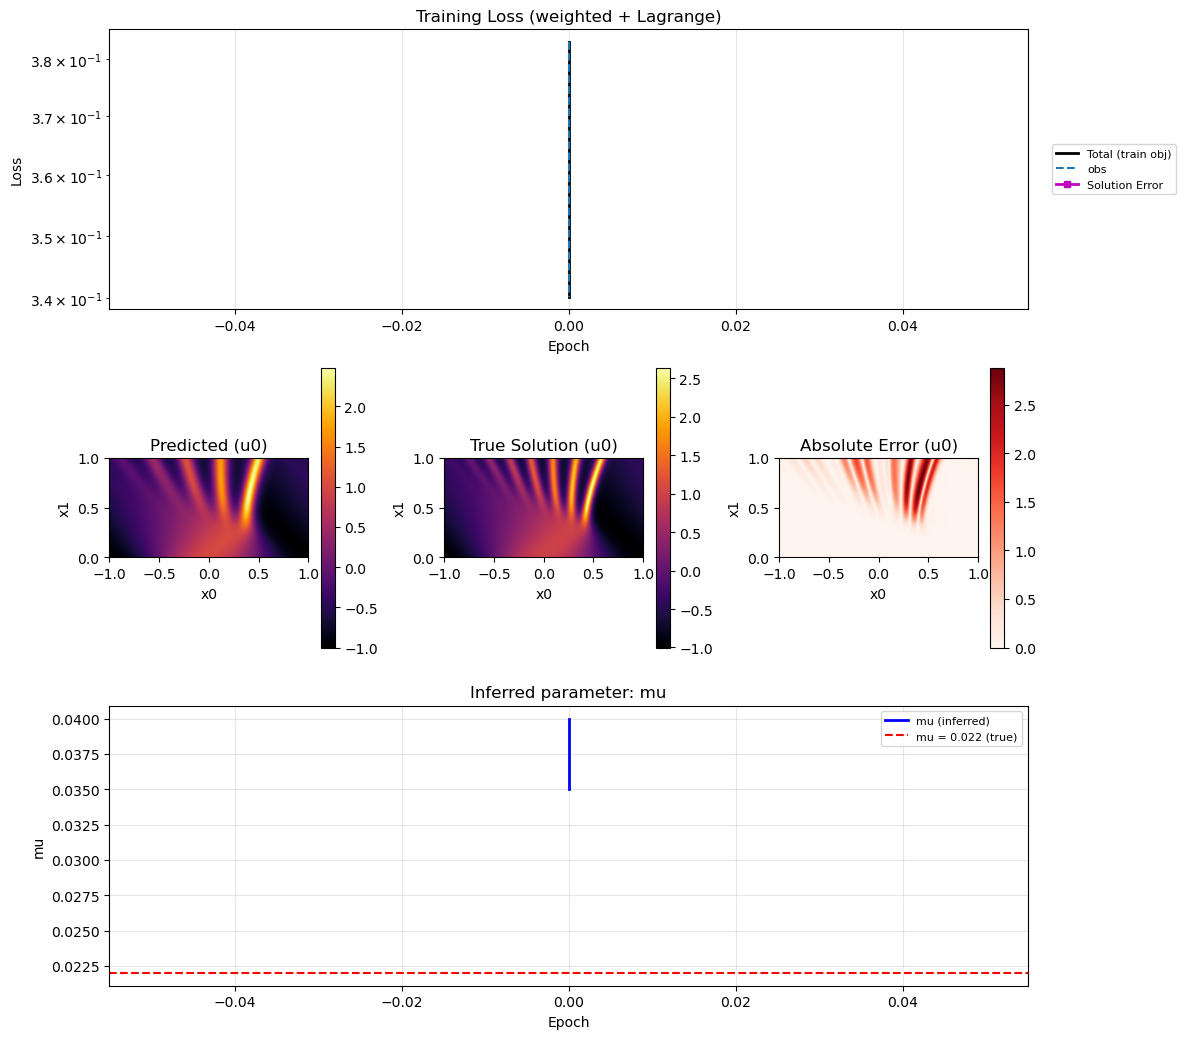

Epoch 0/150 | Loss: 3.83e-01 | MSE: 3.83e-01 | Terms: [] | Data: [obs: 3.83e-01] | Error: N/A | Params: [mu: 0.04] | Time: 0.0s
Epoch 1/150 | Loss: 3.40e-01 | MSE: 3.40e-01 | Terms: [] | Data: [obs: 3.40e-01] | Error: N/A | Params: [mu: 0.035] | Time: 16.9s


W0521 11:26:49.644984 3334828 cuda_command_buffer.cc:780] Retry CUDA graph instantiation after OOM error
E0521 11:26:49.645050 3334828 pjrt_stream_executor_client.cc:3314] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Underlying backend ran out of memory trying to instantiate command buffer with 7 (total of 120 alive graphs in the process). You can try to (a) Give more memory to the driver by reducing XLA_CLIENT_MEM_FRACTION (b) Disable command buffers with 'XLA_FLAGS=--xla_gpu_enable_command_buffer=' (empty set). Original error: Failed to instantiate CUDA graph: CUDA_ERROR_OUT_OF_MEMORY: out of memory


XlaRuntimeError: RESOURCE_EXHAUSTED: Underlying backend ran out of memory trying to instantiate command buffer with 7 (total of 120 alive graphs in the process). You can try to (a) Give more memory to the driver by reducing XLA_CLIENT_MEM_FRACTION (b) Disable command buffers with 'XLA_FLAGS=--xla_gpu_enable_command_buffer=' (empty set). Original error: Failed to instantiate CUDA graph: CUDA_ERROR_OUT_OF_MEMORY: out of memory

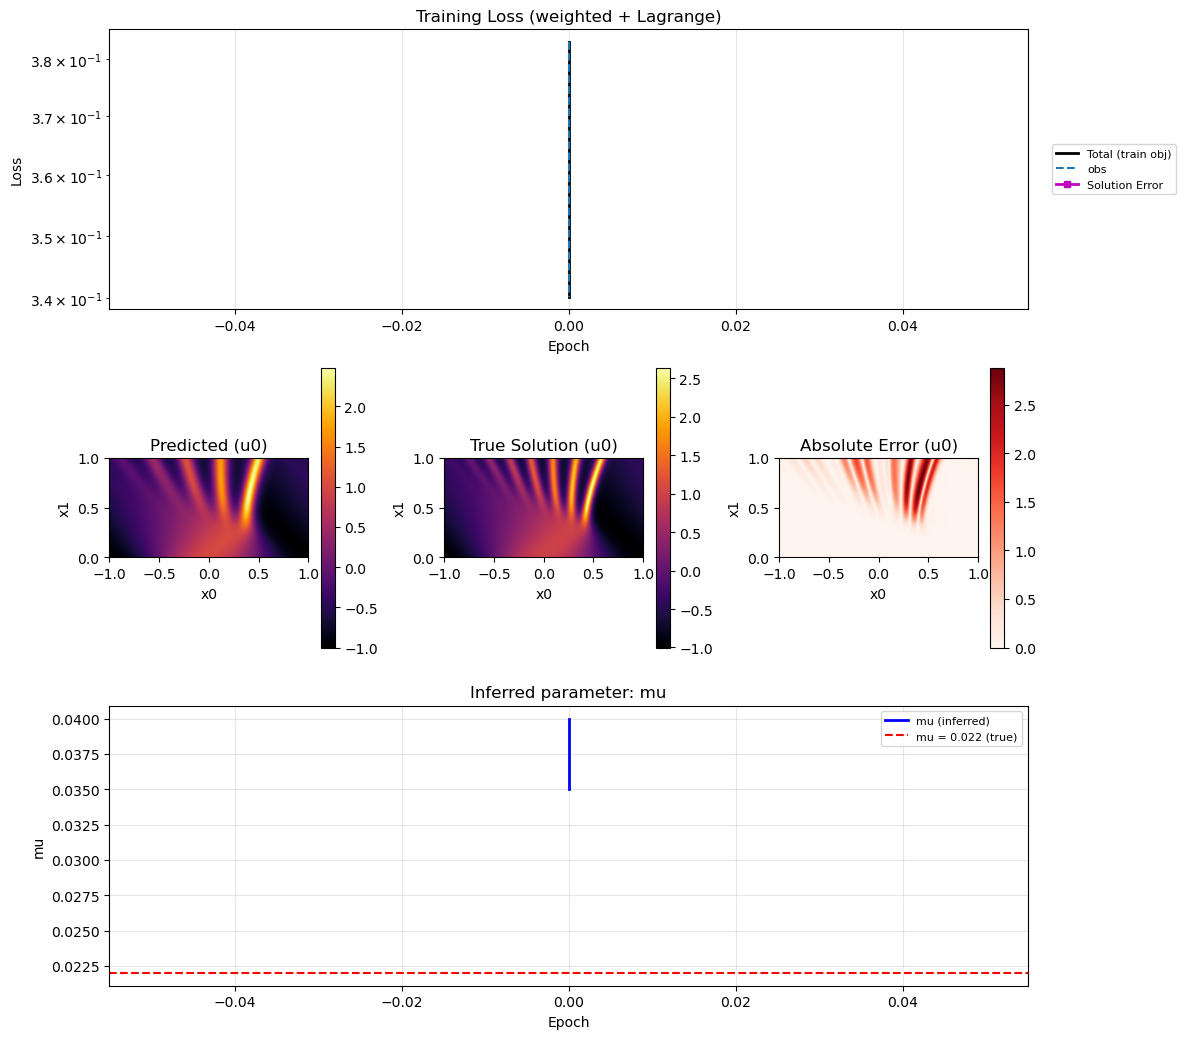

: 

In [ ]:
# ── Noisy observations (1% Gaussian noise on the reference) ─────────────────
U_ref   = np.array(U_etd["u"])   # (Nt, Nx) physical space
rng_np  = np.random.default_rng(42)
U_noisy = U_ref + rng_np.normal(0, 0.01, U_ref.shape)

# ── ModelSpectralSolver with μ as to-be-inferred parameter ───────────────────
integrator_inv = pinns.IntegratorETD2RK(dt=5e-4, checkpoint=True)
model_inv = pinns.ModelSpectralSolver(domain_grid, ["u"], integrator_inv, shape=(Nx,))

model_inv.set_linear_op(
    lambda K2, p: {"u": 1j * p["mu"] ** 2 * model_inv.k * K2}
)

def kdv_nonlinear_inv(state_hat, p):
    u = model_inv.inverse(state_hat["u"])
    return {"u": -1j * p["eta"] / 2.0 * model_inv.k
                 * model_inv.forward(u * u)}

model_inv.set_nonlinear_op(kdv_nonlinear_inv)
model_inv.add_parameter("eta", eta_val)
model_inv.add_parameter("mu",  0.04)   # initial guess
model_inv.add_initial(jnp.cos(jnp.pi * jnp.array(x_ref)))

# Observation times are needed by ModelSpectralSolver.apply for interpolation.
model_inv._obs_times = t_ref

# ── Dataset: scatter (x, t) observation points ──────────────────────────────
# Convention: columns = [x, t]  (spatial first, time last)
T_grid, X_grid = np.meshgrid(t_ref, x_ref, indexing="ij")   # (Nt, Nx)
X_obs      = np.stack([X_grid.ravel(), T_grid.ravel()], axis=-1).astype(np.float32)
U_obs_flat = U_noisy.ravel().astype(np.float32)

idx = rng_np.choice(len(X_obs), size=4096, replace=False)
dataset = pinns.Dataset()
dataset.add_points(X_obs[idx], U_obs_flat[idx], name="obs", component=0)

# ── Reference solution interpolant (ETD2RK ground truth) ────────────────────
from scipy.interpolate import RegularGridInterpolator

_u_ref_interp = RegularGridInterpolator(
    (t_ref, x_ref), U_ref, method="linear", bounds_error=False, fill_value=None
)

def u_reference(xy, params=None):
    """Interpolate ETD2RK reference onto arbitrary (x, t) points.
    xy: (N, 2) array with columns [x_spatial, t]."""
    xt = np.column_stack([xy[:, 1], xy[:, 0]])   # flip to (t, x) for interp
    return _u_ref_interp(xt).reshape(-1, 1)

# ── Trainer (no PDE problem — dataset-only inverse) ──────────────────────────
from pinns.trainer.optimizers import AdamOptimizer

trainer = pinns.Trainer(model_inv, dataset=dataset)
trainer.add_solution(u_reference)
trainer.set_solution_parameter("mu", mu_val)   # true μ = 0.022 shown as reference line
trainer.compile(
    fit_model_parameters=["mu"],
    optimizer=AdamOptimizer(learning_rate=5e-3),
    epochs=150,
    print_each=1,
)
trainer.train()
